In [ ]:
# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin 2197525
- Lara Fogarolo 2199475
- Francesco Peron 2185610

# 0. Generation of the dataset

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and split data

In [6]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Scatter plot on \[i,j\] feature plane

[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


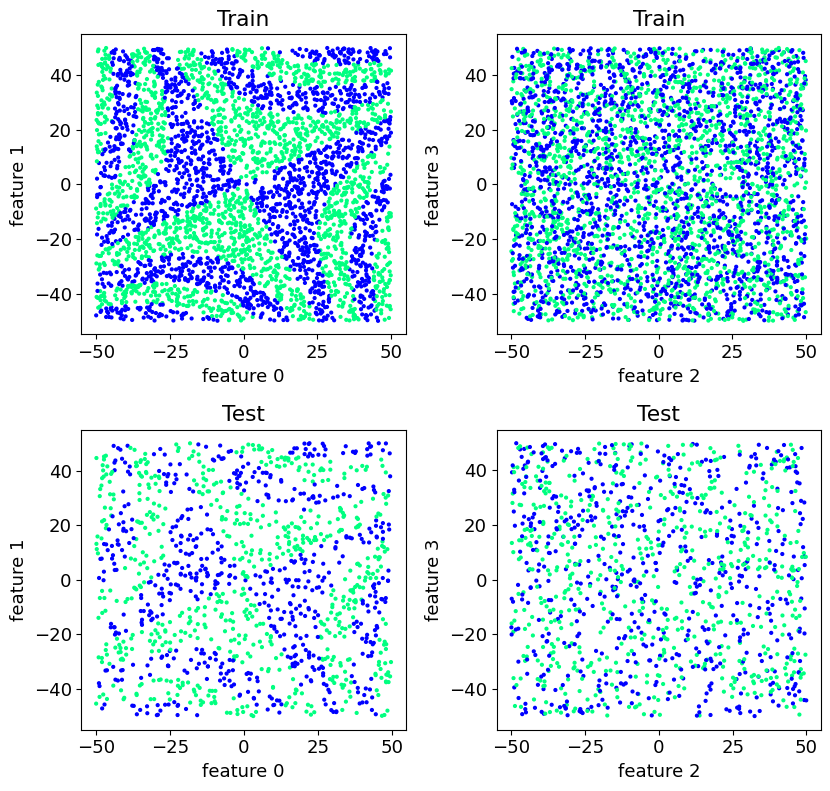

In [7]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

In [8]:
def classify(clf=GradientBoostingClassifier()):
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_test) # predict the labels of the test set

    #defining accuracy as a global variable
    global accuracy
    accuracy = clf.score(x_test, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test, y_test)),clf.score(x_test, y_test)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.64%   Accuracy=0.934
shape of x_plot= (10201, 4)


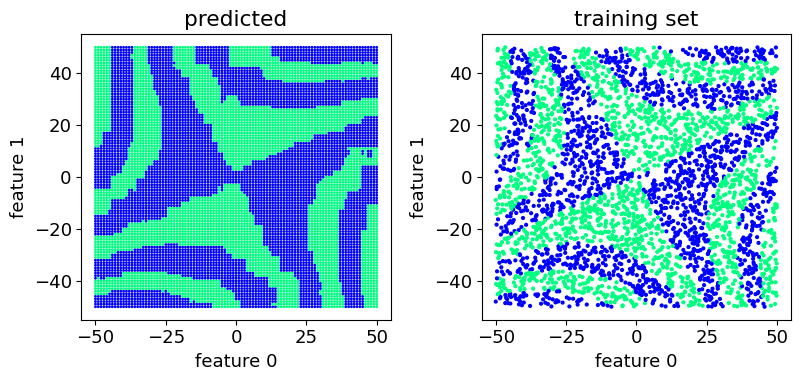

In [9]:
model = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify(model)

gain
[0.41903338 0.44306126 0.06554136 0.07236399]


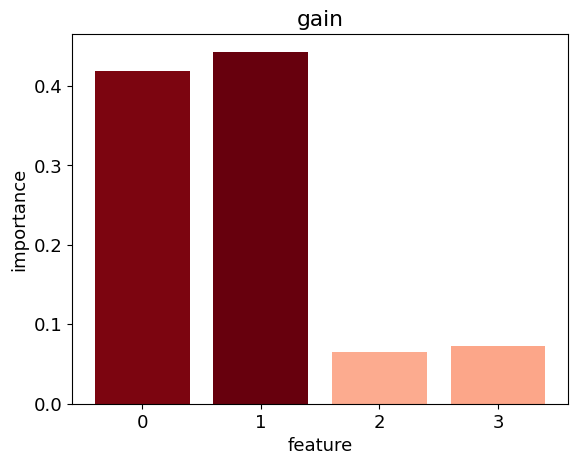

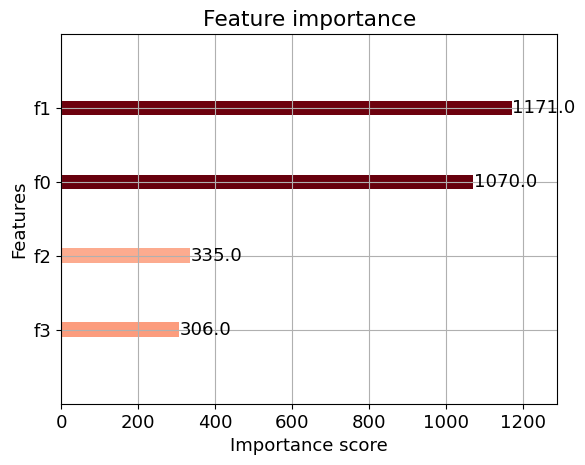

In [10]:
# https://machinelearningmastery.com/feature-importance-and-feature-selection-with-xgboost-in-python/
# feature importance

print(model.importance_type)
print(model.feature_importances_)
# plot
my_cmap = plt.get_cmap("Reds")
# rescale the feature importances to the range [0.3,1] for better visualization
rescale = lambda y: 0.3 + 0.7 * (y - np.min(y)) / (np.max(y) - np.min(y))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_,
        color=my_cmap(rescale(model.feature_importances_)))
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(np.arange(L))
plt.title(model.importance_type)
plt.show()

rescale_r = lambda y: 0.3 + 0.7 * (np.max(y) - y) / (np.max(y) - np.min(y))
plot_importance(model,color=my_cmap(rescale_r(model.feature_importances_)))
plt.show()

# 1. Model complexity, parameters and regularization
In this section we will study the accurcy of the model for different parameters


## Generating accuracy data 

In [7]:
n_estimators_list  = [50, 100, 200, 400]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
lambda_val_list = [0, 0.5, 1, 5, 10, 50, 100]

results = []

for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in  learning_rate_list:
            for l in lambda_val_list:
                model = XGBClassifier(
                seed=1,
                objective='binary:logistic',
                importance_type="gain",
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                reg_lambda=l
                )
            
                model.fit(x_train, y_train)
                acc_train = model.score(x_train, y_train)
                acc_val   = model.score(x_test, y_test)
                results.append((n_est, depth, lr, l, acc_train, acc_val))



## Test accuracy vs all variables studied

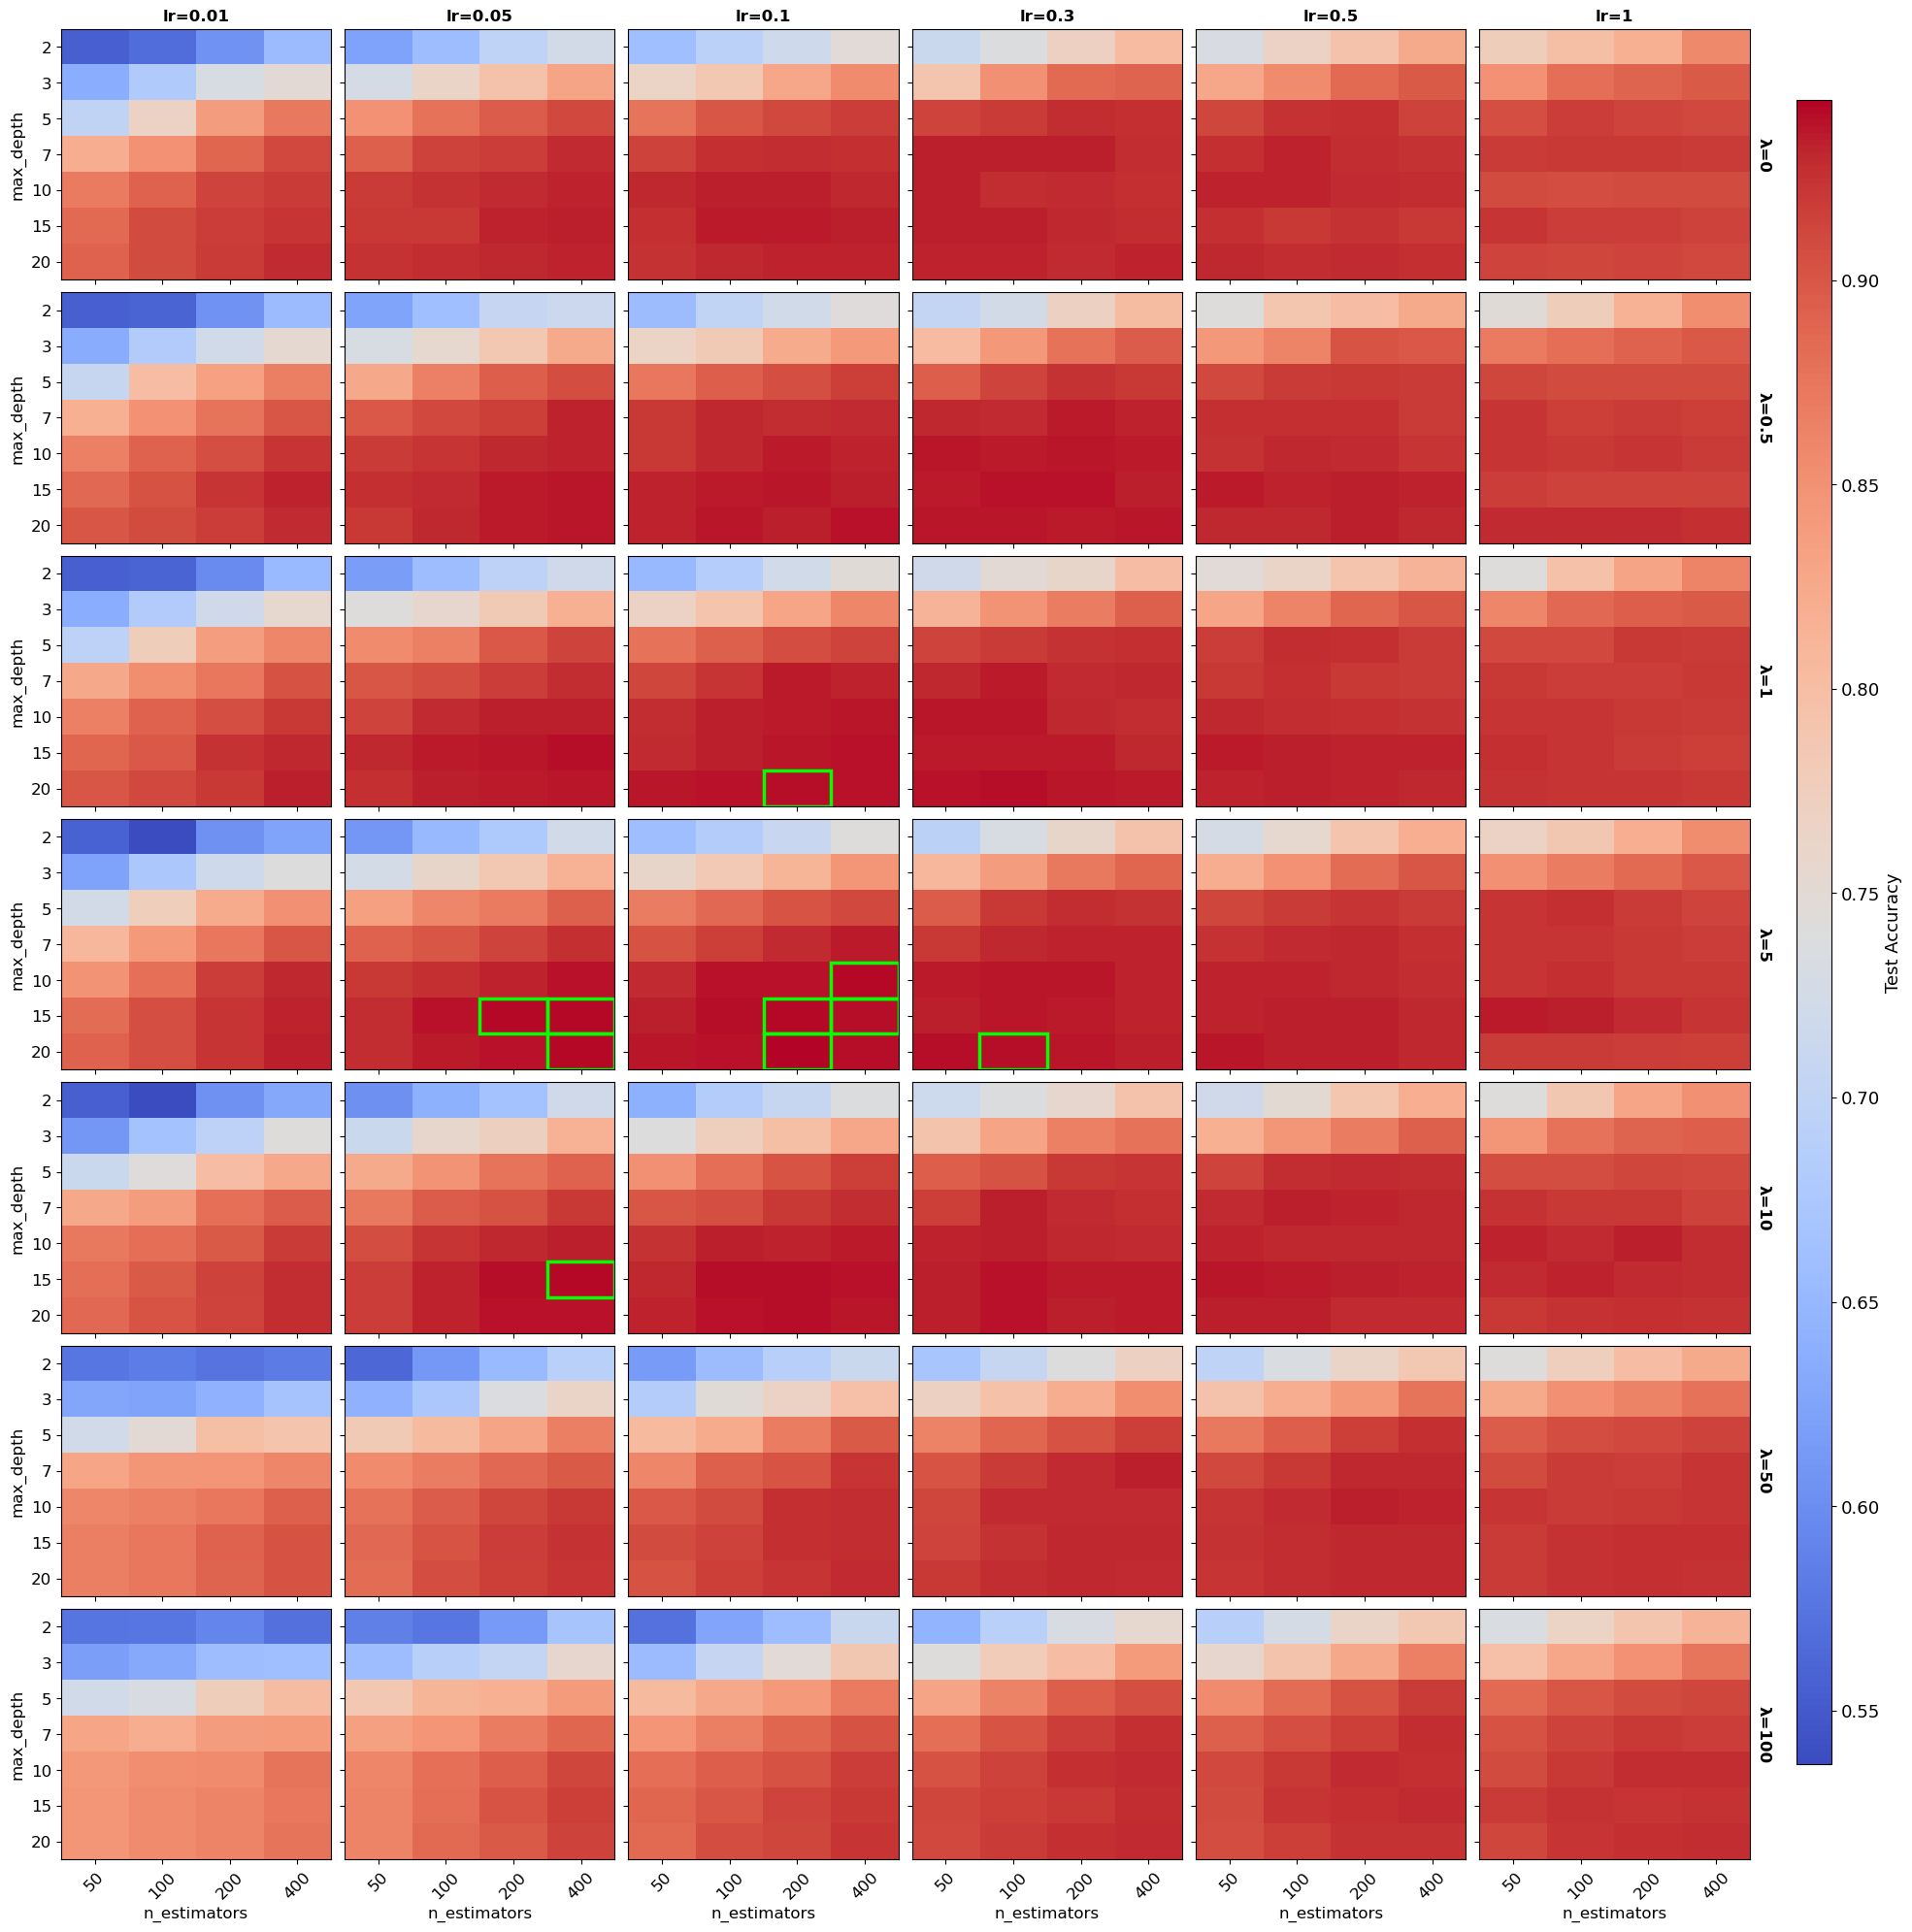

In [8]:
"""
import pickle


with open('ex3_results.pkl', 'wb') as f:
    pickle.dump(results, f)

"""
n_estimators_list  = [50, 100, 200, 400]
max_depth_list     = [2, 3, 5, 7, 10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5, 1]
lambda_val_list = [0, 0.5, 1, 5, 10, 50, 100]

n_nest  = len(n_estimators_list)
n_depth = len(max_depth_list)
n_lr    = len(learning_rate_list)
n_lam   = len(lambda_val_list)


acc_val_grid = np.zeros((n_nest, n_depth, n_lr, n_lam))

for n_est, depth, lr, lam, _, acc_val in results:
    i = n_estimators_list.index(n_est)
    j = max_depth_list.index(depth)
    k = learning_rate_list.index(lr)
    l = lambda_val_list.index(lam)
    acc_val_grid[i, j, k, l] = acc_val

vmin = np.min(acc_val_grid)
vmax = np.max(acc_val_grid)

fig, axes = plt.subplots(
    n_lam, n_lr,
    figsize=(4 * n_lr, 3.5 * n_lam),
    sharex=True, sharey=False
)

for row, lam in enumerate(lambda_val_list):
    for col, lr in enumerate(learning_rate_list):

        ax = axes[row, col]
       
        heatmap = acc_val_grid[:, :, col, row].T  
        im = ax.imshow(heatmap, aspect='auto', cmap='coolwarm',
                       vmin=vmin, vmax=vmax, origin='upper')

        ax.set_xticks(range(n_nest))
        ax.set_yticks(range(n_depth))
        
        if row == n_lam - 1:
            ax.set_xticklabels(n_estimators_list, rotation=45, fontsize=12)
            ax.set_xlabel('n_estimators', fontsize=12)
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_yticklabels(max_depth_list, fontsize=12)
            ax.set_ylabel('max_depth', fontsize=12)
        else:
            ax.set_yticklabels([])

        
        if row == 0:
            ax.set_title(f'lr={lr}', fontsize=12, fontweight='bold')

        if col == n_lr - 1:
            ax.yaxis.set_label_position('right')
            ax.set_ylabel(f'λ={lam}', fontsize=12, fontweight='bold', rotation=270, labelpad=16)

fig.subplots_adjust(right=0.85, hspace=0.05, wspace=0.05)
cbar_ax = fig.add_axes([0.87, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Test Accuracy')

#to higlight the best 10
flat_indices = np.argsort(acc_val_grid.ravel())[-10:]
top_coords = np.array(np.unravel_index(flat_indices, acc_val_grid.shape)).T  

for row, lam in enumerate(lambda_val_list):
    for col, lr in enumerate(learning_rate_list):
        ax = axes[row, col]
        heatmap = acc_val_grid[:, :, col, row].T 

        for (i, j, k, l) in top_coords:
            if k == col and l == row:
                
                rect = plt.Rectangle((i - 0.5, j - 0.5), 1, 1,
                                     linewidth=2.5, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)

plt.show()


## Marginal accuracy 
Here we do the mean of the accuracy keeping one parameter fixed at time

Text(0.5, 0.98, 'Marginal accuracy')

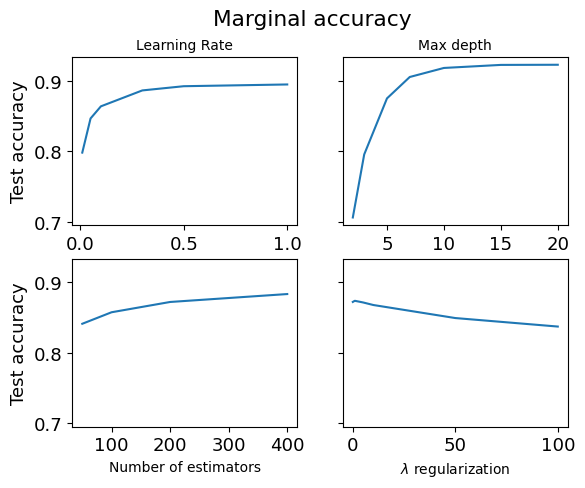

In [9]:
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
mean_val_vs_lambda = []
results = np.array(results)

    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 5]))

for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 5]))
    
for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 5]))
    

    
for l in lambda_val_list:
    mask = results[:,3] == l
    mean_val_vs_lambda.append(np.mean(results[mask, 5]))
    

fig, axes = plt.subplots(nrows=2,ncols=2, sharey=True)

axes[0][0].plot(learning_rate_list, mean_val_vs_lr)
axes[0][0].set_title("Learning Rate", fontsize=10)
axes[0][0].set_ylabel("Test accuracy")
axes[0][1].plot(max_depth_list, mean_val_vs_depth)
axes[0][1].set_title("Max depth", fontsize=10)
axes[1][0].plot(n_estimators_list, mean_val_vs_nest)
axes[1][0].set_xlabel("Number of estimators", fontsize=10)
axes[1][0].set_ylabel("Test accuracy")
axes[1][1].plot(lambda_val_list, mean_val_vs_lambda)
axes[1][1].set_xlabel("$\lambda$ regularization", fontsize=10)
fig.suptitle("Marginal accuracy")

The test accuracy seems to have a maximum around lambda=1... We zoom the plot

Text(0.5, 0.98, 'Marginal accuracy')

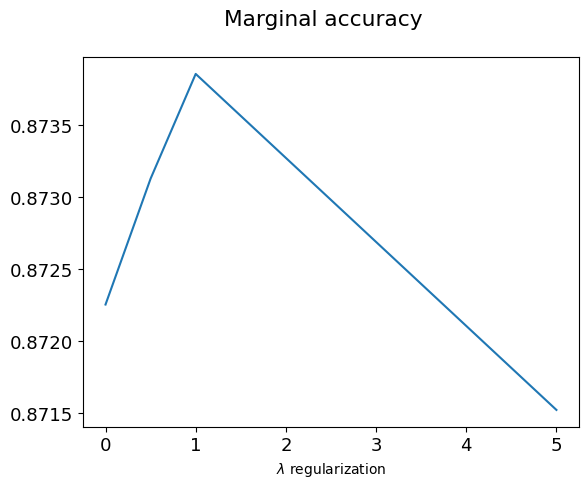

In [10]:
results = np.array(results)
mean_val_vs_lambda = []
lambda_val_list = [0, 0.5, 1, 5]
for l in lambda_val_list:
    mask = results[:,3] == l
    mean_val_vs_lambda.append(np.mean(results[mask, 5]))

fig, ax = plt.subplots(1,1)
ax.plot(lambda_val_list, mean_val_vs_lambda)
ax.set_xlabel("$\lambda$ regularization", fontsize=10)
fig.suptitle("Marginal accuracy")

## Does anything change if we zoom around the maxiumum region? (Not really)

Text(0.5, 0.98, 'Marginal accuracy')

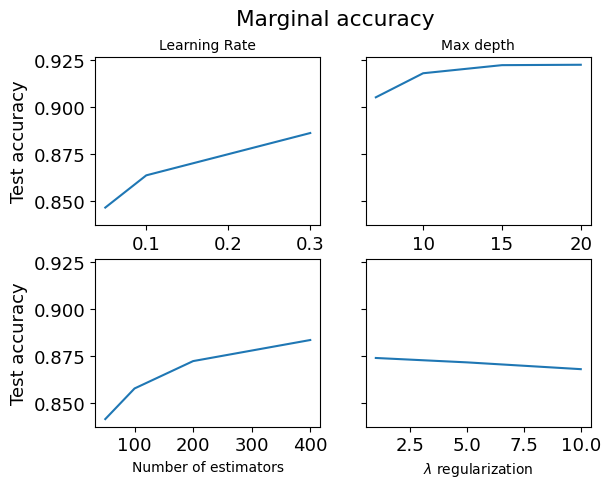

In [11]:
n_estimators_list  = [50, 100, 200, 400]
max_depth_list     = [7, 10, 15, 20]
learning_rate_list = [0.05, 0.1, 0.3]
lambda_val_list = [1, 5, 10,]
mean_val_vs_lr = []
mean_val_vs_depth = []
mean_val_vs_nest = []
mean_val_vs_lambda = []
results = np.array(results)

    
for n_est in n_estimators_list:
    mask = results[:,0] == n_est
    mean_val_vs_nest.append(np.mean(results[mask, 5]))

for depth in max_depth_list:
    mask = results[:,1] == depth
    mean_val_vs_depth.append(np.mean(results[mask, 5]))
    
for lr in learning_rate_list:
    mask = results[:,2] == lr
    mean_val_vs_lr.append(np.mean(results[mask, 5]))
    

    
for l in lambda_val_list:
    mask = results[:,3] == l
    mean_val_vs_lambda.append(np.mean(results[mask, 5]))
    

fig, axes = plt.subplots(nrows=2,ncols=2, sharey=True)

axes[0][0].plot(learning_rate_list, mean_val_vs_lr)
axes[0][0].set_title("Learning Rate", fontsize=10)
axes[0][0].set_ylabel("Test accuracy")
axes[0][1].plot(max_depth_list, mean_val_vs_depth)
axes[0][1].set_title("Max depth", fontsize=10)
axes[1][0].plot(n_estimators_list, mean_val_vs_nest)
axes[1][0].set_xlabel("Number of estimators", fontsize=10)
axes[1][0].set_ylabel("Test accuracy")
axes[1][1].plot(lambda_val_list, mean_val_vs_lambda)
axes[1][1].set_xlabel("$\lambda$ regularization", fontsize=10)
fig.suptitle("Marginal accuracy")

## Final Comment
From the marginal test accuracy plots we can observe the following:

### Max Depth
Max depth has the biggest impact on accuracy. For small values accuracy drops significantly, while it stabilizes around 10–15. This is consistent with the structure of the data: as we see in the scatter plots, the decision boundary between the two classes follows a hyperbolic shape in the plane, which requires combining several stumps to be approximated. With small max depth this is not possible.

### Learning Rate
This is the second most important parameter. For small values the model tends not to converge, likely because the step is too small and many more estimators would be needed to reach a good solution.

### L2 Regularization
Regularization works well around $\lambda$=1, which represents a good tradeoff between an overly conservative model (large $\lambda$) and an overly complex one which tends to overfit ( $\lambda$=0). Since the true boundary is non-linear, it is not surprising that large  $\lambda$ values hurt performance.

### Number of Estimators
Already 50 estimators bring to a quite stable model, suggesting that the booster converges quickly at sufficient learning rate.

# 2. Dimensionality reduction

In [11]:
#redefining x_train and x_test without the feauture 3
x_train_012 = x_train[:, :3]
x_test_012 = x_test[:, :3]

In [13]:
#redifining the classification with the new datasets of training and test
def classify_012(clf=GradientBoostingClassifier()):

    clf.fit(x_train_012,y_train) 
    y_hat = clf.predict(x_test_012) 

    global accuracy_012
    accuracy_012 = clf.score(x_test_012, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_012, y_test)),clf.score(x_test_012, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-1))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_012[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.88%   Accuracy=0.931
shape of x_plot= (10201, 3)


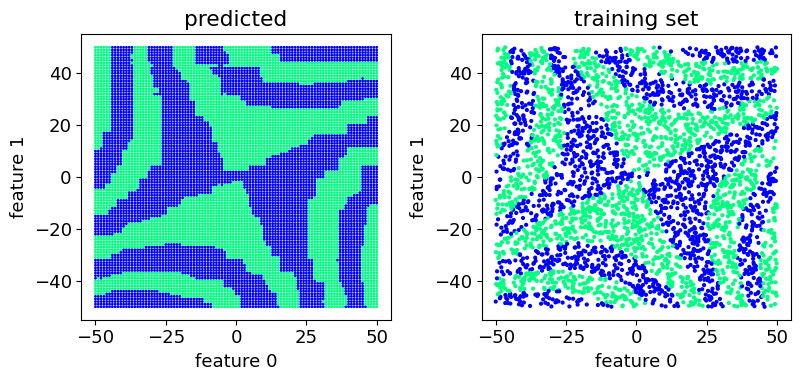

In [14]:
model_012 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_012(model_012)

In [15]:
#redefining x_train and x_test without the feauture 3 and 2
x_train_01 = x_train[:, :2]
x_test_01 = x_test[:, :2]

In [16]:
#redifining the classification with the new datasets of training and test
def classify_01(clf=GradientBoostingClassifier()):

    clf.fit(x_train_01,y_train) 
    y_hat = clf.predict(x_test_01) 

    global accuracy_01
    accuracy_01 = clf.score(x_test_01, y_test)
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_test_01, y_test)),clf.score(x_test_01, y_test)))
    S=50 
    dx = 1
    x_seq=np.arange(-S,S+dx,dx)
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L-2))
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] 
            q+=1
    y_plot= clf.predict(x_plot) 

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train_01[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()

errors: 6.24%   Accuracy=0.938
shape of x_plot= (10201, 2)


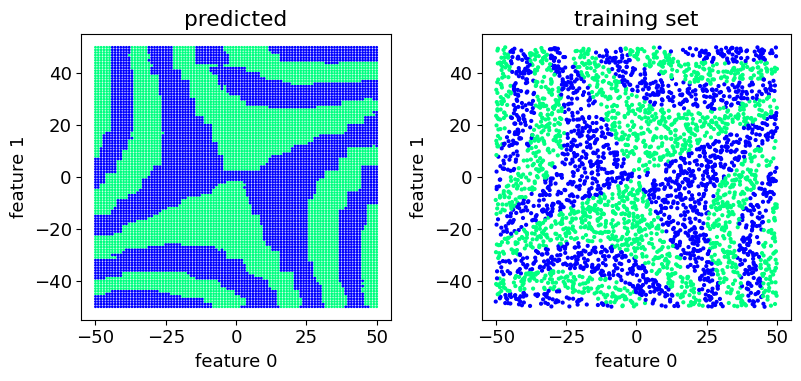

In [17]:
model_01 = XGBClassifier(seed=1,
                      objective='binary:logistic',
                      importance_type="gain") 
classify_01(model_01)

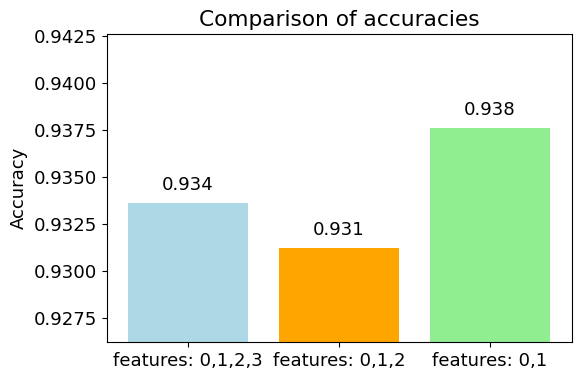

In [18]:
plt.figure(figsize=(6,4))
accuracies = [accuracy, accuracy_012, accuracy_01]
labels = ['features: 0,1,2,3', 'features: 0,1,2', 'features: 0,1']
bars = plt.bar(labels, accuracies, color=['lightblue','orange','lightgreen'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.3f}", ha='center', va='bottom')


plt.ylim(min(accuracies)-0.005, max(accuracies)+0.005) 
plt.ylabel("Accuracy")
plt.title("Comparison of accuracies")
plt.show()

## Comment on accuracies
As we can see from the plot the accuracy using only feautures 0 and 1 is higher than the others, that's because feutures 2 and 3 are not informative about the dataset. Removing only the third feature doesn't improve the accuracy because of the stochastic process introduced by feature 2. 

# 3. XGBoost vs NN

We compare our XGB model with 0,1,2 features against the generic FFNN out assignment 1, with and without tuning, to see their performance.

2026-03-26 19:49:43.661006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774550988.288602    6052 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2182 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-03-26 19:49:50.644875: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b33d400ab30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-26 19:49:50.644885: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 SUPER, Compute Capability 7.5
2026-03-26 19:49:50.720132: I tensorflow/compiler/mlir/tensorflow/utils/dump_

N'=250: XGB1=0.636±0.083 | XGB2=0.636±0.083 | FFNN=0.516±0.064
N'=500: XGB1=0.748±0.040 | XGB2=0.748±0.040 | FFNN=0.524±0.029
N'=1000: XGB1=0.805±0.018 | XGB2=0.805±0.018 | FFNN=0.510±0.021
N'=1500: XGB1=0.858±0.017 | XGB2=0.858±0.017 | FFNN=0.513±0.028
N'=2500: XGB1=0.901±0.010 | XGB2=0.901±0.010 | FFNN=0.539±0.023
N'=3500: XGB1=0.927±0.011 | XGB2=0.927±0.011 | FFNN=0.532±0.023
N'=4500: XGB1=0.939±0.011 | XGB2=0.939±0.011 | FFNN=0.593±0.024


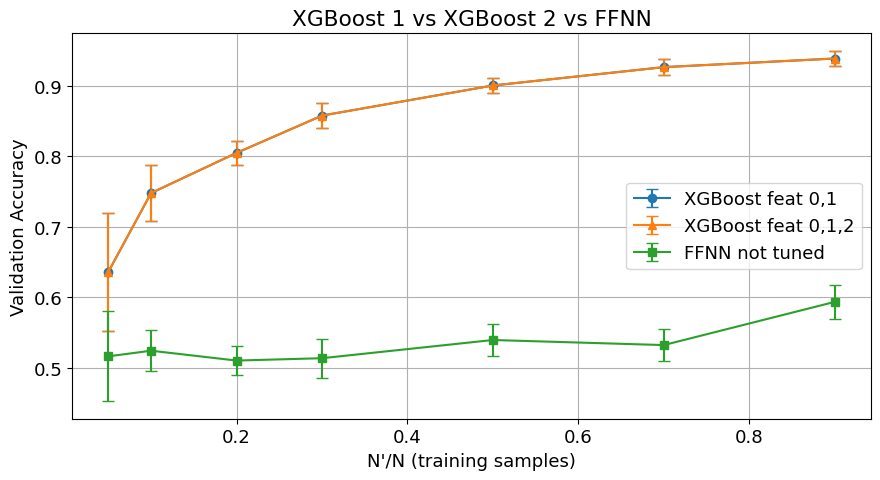

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout

def build_ffnn(L):
    model = keras.Sequential([
        layers.Input(shape=(L,)),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(20, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

fraction = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_xgb1, std_xgb1 = [], []
acc_xgb2, std_xgb2 = [], []
acc_ffnn,  std_ffnn  = [], []

for frac in fraction:
    N_prime = int(N * frac)
    idx = np.random.choice(N, N_prime, replace=False)
    X_sub = x[idx]
    y_sub = y[idx]

    # --- XGBoost 1 ---
    scores1 = cross_val_score(model_01, X_sub, y_sub, cv=kf, scoring='accuracy')
    acc_xgb1.append(scores1.mean())
    std_xgb1.append(scores1.std())

    # --- XGBoost 2 ---
    scores2 = cross_val_score(model_012, X_sub, y_sub, cv=kf, scoring='accuracy')
    acc_xgb2.append(scores2.mean())
    std_xgb2.append(scores2.std())

    # --- FFNN ---
    fold_scores_ffnn = []
    for train_idx, val_idx in kf.split(X_sub, y_sub):
        X_train, X_val = X_sub[train_idx], X_sub[val_idx]
        y_train, y_val = y_sub[train_idx], y_sub[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        model = build_ffnn(L)
        model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_scores_ffnn.append(acc)

    acc_ffnn.append(np.mean(fold_scores_ffnn))
    std_ffnn.append(np.std(fold_scores_ffnn))

    print(f"N'={N_prime}: "
          f"XGB1={acc_xgb1[-1]:.3f}±{std_xgb1[-1]:.3f} | "
          f"XGB2={acc_xgb2[-1]:.3f}±{std_xgb2[-1]:.3f} | "
          f"FFNN={acc_ffnn[-1]:.3f}±{std_ffnn[-1]:.3f}")

# --- Plot ---
N_primes = [int(N * f) for f in fraction]

plt.figure(figsize=(9, 5))
plt.errorbar(fraction, acc_xgb1, yerr=std_xgb1, marker='o', capsize=4, label='XGBoost feat 0,1')
plt.errorbar(fraction, acc_xgb2, yerr=std_xgb2, marker='^', capsize=4, label='XGBoost feat 0,1,2')
plt.errorbar(fraction, acc_ffnn,  yerr=std_ffnn,  marker='s', capsize=4, label='FFNN not tuned')
plt.xlabel("N'/N (training samples)")
plt.ylabel("Validation Accuracy")
plt.title("XGBoost 1 vs XGBoost 2 vs FFNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We can see that with N'/N small, XGB with 2 and 3 features has a better perfomance with respect to the FFNN, as we expect. Even for N'/N close to 1 the accuracy of the FFNN isn't improving. To improve the perfomance of the FFNN, we try to tune it using k-fold cross validation method.

In [19]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import keras_tuner as kt

def build_model(hp):
    model = Sequential([
        Input(shape=(L,)),
        Dense(L, activation='relu'),
    ])

    # Hyperparameters
    dropout_rate  = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
    activation    = hp.Choice("activation", values=["relu", "elu"])
    learning_rate = hp.Float("learning_rate", min_value=1e-6, max_value=1e-1, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    # Inner layers
    for _ in range(3):
        model.add(Dense(20, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    optimizers = {
        "adam":    keras.optimizers.Adam(learning_rate=learning_rate),
        "sgd":     keras.optimizers.SGD(learning_rate=learning_rate),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=learning_rate),
        "nadam":   keras.optimizers.Nadam(learning_rate=learning_rate),
    }

    model.compile(
        optimizer=optimizers[optimizer_name],
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
outer_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
fraction = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
acc_xgb, std_xgb = [], []
acc_ffnn_tuned, std_ffnn_tuned = [], []

for frac in fraction:
    N_prime = int(N * frac)
    idx = np.random.choice(N, N_prime, replace=False)
    X_sub, y_sub = x[idx], y[idx]
    
    # --- XGBoost (outer CV) ---
    scores_xgb = cross_val_score(model_01, X_sub, y_sub,
                                  cv=outer_kf, scoring='accuracy')
    acc_xgb.append(scores_xgb.mean())
    std_xgb.append(scores_xgb.std())
    
    # --- FFNN con tuning (nested CV) ---
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(outer_kf.split(X_sub, y_sub)):
        X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
        y_tr, y_val = y_sub[train_idx], y_sub[val_idx]
    
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)
    
        X_inner_tr, X_inner_val, y_inner_tr, y_inner_val = train_test_split(
            X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42
        )
    
        tuner = kt.RandomSearch(
            build_model,                          
            objective='val_accuracy',
            max_trials=10,
            executions_per_trial=1,
            directory=f'tuner_frac{frac}_fold{fold}',
            project_name='ffnn_search',
            overwrite=True
        )
    
        tuner.search(
            X_inner_tr, y_inner_tr,
            validation_data=(X_inner_val, y_inner_val),
            epochs=50,
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)],
            verbose=0
        )
    
        # Riaddestra il miglior modello su tutto il fold di training
        best_hp = tuner.get_best_hyperparameters(1)[0]
        best_model = build_model(best_hp)
        best_model.fit(X_tr, y_tr, epochs=80, batch_size=32, verbose=0)
    
        _, acc = best_model.evaluate(X_val, y_val, verbose=0)
        fold_scores.append(acc)
        
    acc_ffnn_tuned.append(np.mean(fold_scores))
    std_ffnn_tuned.append(np.std(fold_scores))
    
    print(f"N'={N_prime}: XGB={acc_xgb[-1]:.3f}±{std_xgb[-1]:.3f} | "
              f"FFNN tuned={acc_ffnn_tuned[-1]:.3f}±{std_ffnn_tuned[-1]:.3f}")




N_primes = [int(N * f) for f in fraction]

plt.figure(figsize=(9, 5))
plt.errorbar(fraction, acc_ffnn,  yerr=std_ffnn,  marker='s', capsize=4, label='FFNN not tuned')
plt.errorbar(fraction, acc_xgb, yerr=std_xgb,
             marker='o', label='XGBoost', capsize=4)
plt.errorbar(fraction, acc_ffnn_tuned, yerr=std_ffnn_tuned,
             marker='s', label='FFNN (tuned)', capsize=4, linestyle='--')
plt.xlabel("N'/N (training samples)")
plt.ylabel("Validation Accuracy")
plt.title("XGBoost vs FFNN tuned — nested CV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

I0000 00:00:1774557904.331414  415262 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2243 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-03-26 21:45:06.001004: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f739c0047e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-26 21:45:06.001015: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 SUPER, Compute Capability 7.5
2026-03-26 21:45:06.019980: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-26 21:45:06.126926: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
I0000 00:00:1774557906.782066  416771 device_compiler.h:196] Compiled cluster using XLA!  This line is l

Epoch 1/80
7/7 - 2s - 351ms/step - accuracy: 0.3850 - loss: 0.7091
Epoch 2/80
7/7 - 0s - 6ms/step - accuracy: 0.3600 - loss: 0.7079
Epoch 3/80
7/7 - 0s - 5ms/step - accuracy: 0.4200 - loss: 0.7031
Epoch 4/80
7/7 - 0s - 5ms/step - accuracy: 0.4300 - loss: 0.7040
Epoch 5/80
7/7 - 0s - 5ms/step - accuracy: 0.4150 - loss: 0.7095
Epoch 6/80
7/7 - 0s - 5ms/step - accuracy: 0.4150 - loss: 0.7048
Epoch 7/80
7/7 - 0s - 5ms/step - accuracy: 0.3850 - loss: 0.7034
Epoch 8/80
7/7 - 0s - 5ms/step - accuracy: 0.4300 - loss: 0.7054
Epoch 9/80
7/7 - 0s - 5ms/step - accuracy: 0.4150 - loss: 0.7067
Epoch 10/80
7/7 - 0s - 5ms/step - accuracy: 0.4150 - loss: 0.6977
Epoch 11/80
7/7 - 0s - 5ms/step - accuracy: 0.4200 - loss: 0.7067
Epoch 12/80
7/7 - 0s - 5ms/step - accuracy: 0.4100 - loss: 0.7082
Epoch 13/80
7/7 - 0s - 5ms/step - accuracy: 0.4200 - loss: 0.7079
Epoch 14/80
7/7 - 0s - 5ms/step - accuracy: 0.4000 - loss: 0.7096
Epoch 15/80
7/7 - 0s - 5ms/step - accuracy: 0.4050 - loss: 0.7064
Epoch 16/80
7/7 -

Even a (not perfectly, because of computational costs) tuned FFNN does not surpass the XGB model in terms of accuracy. The only thing we could try to give the FFNN a chance is to use BayesanOptimizer, and not RandomSearch, to concentrate the hyperparameters where we get the best accuracy.